# Dự án EDA — Phân tích & định giá kim cương (bộ `diamonds`)

## 1. Bối cảnh nghiệp vụ 

Bạn là **Data Scientist** mới vào một công ty bán lẻ kim cương trực tuyến. Ban giám đốc đang nghi ngờ rằng việc định giá hiện tại "cảm tính" và muốn hiểu **giá kim cương thật sự bị chi phối bởi yếu tố nào**. Họ giao cho bạn bộ dữ liệu ~54.000 viên đã bán và yêu cầu một báo cáo EDA trả lời được:

> *"Yếu tố nào quyết định giá nhiều nhất? Có chỗ nào trong dữ liệu đáng ngờ không? Và liệu '4C' (carat, cut, color, clarity) có ảnh hưởng đến giá đúng như trực giác của dân trong ngành không?"*

Sản phẩm cuối là **một notebook EDA mạch lạc** mà một người không chuyên kỹ thuật vẫn đọc hiểu được kết luận — đúng kiểu tài liệu bạn sẽ phải nộp khi đi làm.

**Bảng mô tả cột**

| Cột| Mô tả | 
| ------------- | ------------- | 
| carat | trọng lượng (càng nặng thường càng đắt) |
| cut | chất lượng cắt, từ thấp → cao: Fair < Good < Very Good < Premium < Ideal | 
| color | màu, từ tốt → kém: D, E, F, G, H, I, J (D đẹp nhất) |
| clarity | độ trong, từ kém → tốt: I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF | 
| depth, table | các tỷ lệ hình học của viên đá (%) |
| price | giá (USD) | 
| x, y, z | kích thước dài/rộng/cao (mm) |


In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2. Data Quality Audit

Nhận xét tổng quan về chất lượng dữ liệu:
- Dữ liệu có 53940 dòng, không có dữ liệu thiếu (missing value), có 3 biến phân loại và 6 biến số.
- Dữ liệu có 146 dòng bị lặp (đã xử lý).
- Dữ liệu có 19 dòng dữ liệu không hợp lý: chiều cao, chiều dài hoặc chiều rộng của kim cương bằng 0 (đã xử lý).

Sau khi xử lý, dữ liệu còn lại 53775 dòng.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [3]:
df.duplicated().sum()

np.int64(146)

In [4]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
df = df[(df[['x', 'y', 'z']] != 0).all(axis=1)]
df.describe()

,carat,depth,table,price,x,y,z
count,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000
mean,0.797536,61.748232,57.457806,3931.220288,5.731579,5.734909,3.539964
std,0.473169,1.429639,2.233257,3985.918716,1.118611,1.139451,0.702017
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.030000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 3. Detect outlier & unreasonable value

Kiểm tra chuyên sâu để phát hiện dữ liệu lỗi, có sử dụng kiến thức chuyên ngành:
- Phát hiện các kích thước (chiều dài, chiều rộng, chiều cao) của kim cương có tương quan gần tuyến tính với trọng lượng (carat). Có 3 trường hợp không hợp lý: kim cương có khối lượng lớn nhưng kích thước lại rất nhỏ, xử lý bằng cách loại dữ liệu.
- Trong lĩnh vực kim cương, depth được tính theo công thức: $$depth = \frac{2z}{x+y}\times 100.$$ Thực hiện tính lại depth theo công thức và so sánh với giá trị depth trong dữ liệu. Phát hiện 48 trường hợp có độ chênh lệch >2%, loại các dữ liệu này.
- Thông thường, giá trị depth của kim cương dao động từ 55% đến 70%. Phát hiện có 2 dòng có depth >75%, dựa vào boxplot loại các dữ liệu này.
- Table percentage (table) là chiều rộng của mặt trên cùng chia cho chiều rộng lớn nhất của viên đá. Mức bình thường là 50% - 70%. Phát hiện có 1 dòng có table >90%, dựa vào boxplot loại các dữ liệu này.


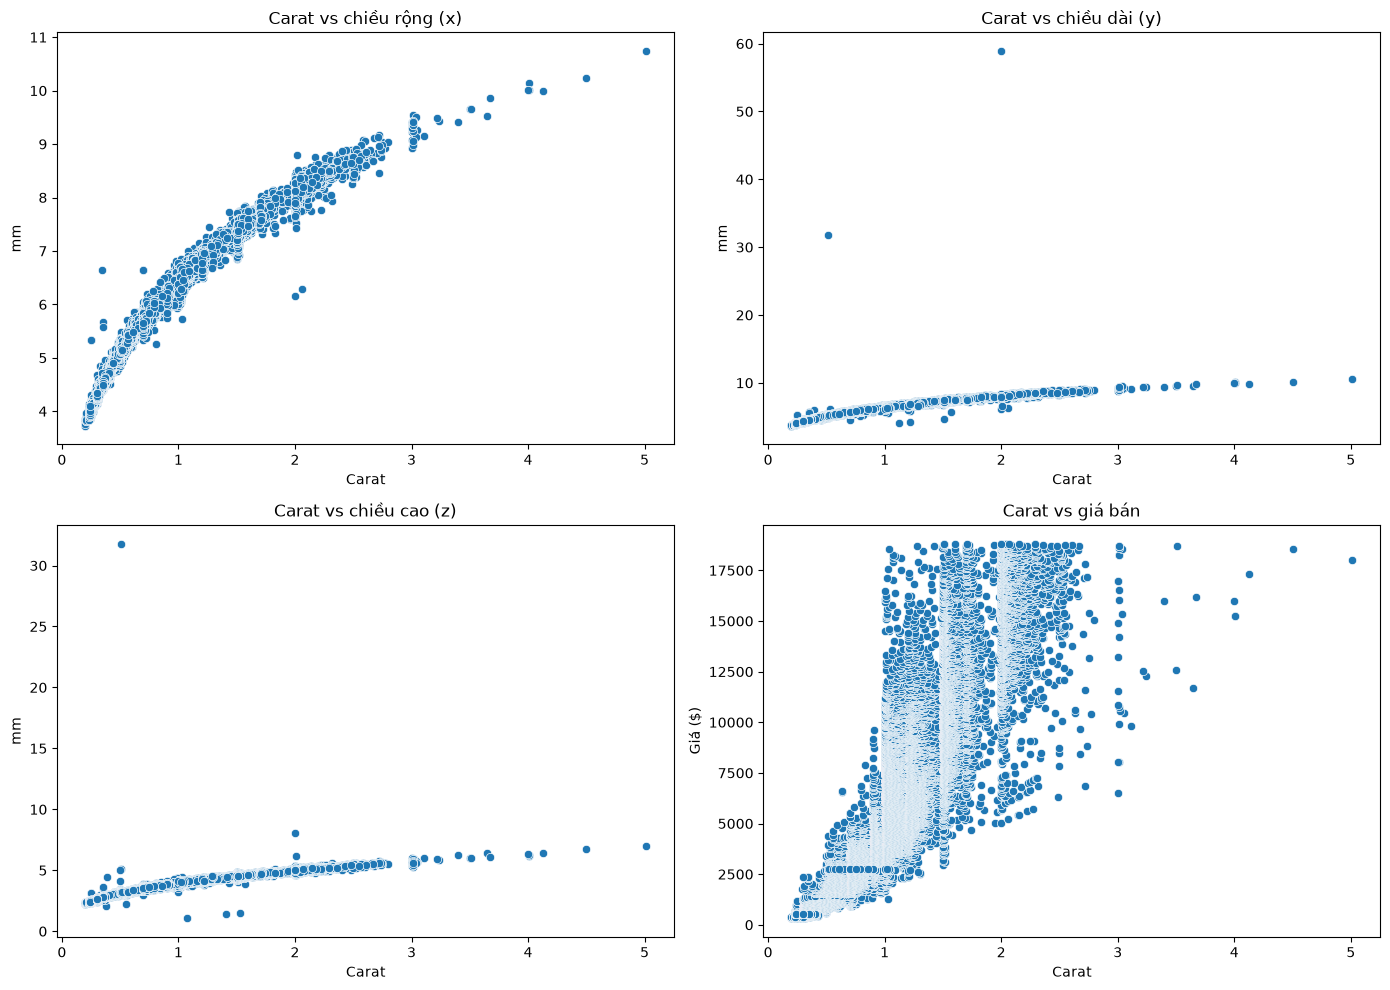

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# - Dòng 1, Cột 1
sns.scatterplot(data=df, x='carat', y='x', ax=axs[0, 0])
axs[0, 0].set_title('Carat vs chiều rộng (x)')
axs[0, 0].set_xlabel('Carat')
axs[0, 0].set_ylabel('mm')

# - Dòng 1, Cột 2
sns.scatterplot(data=df, x='carat', y='y', ax=axs[0, 1])
axs[0, 1].set_title('Carat vs chiều dài (y)')
axs[0, 1].set_xlabel('Carat')
axs[0, 1].set_ylabel('mm')

# - Dòng 2, Cột 1
sns.scatterplot(data=df, x='carat', y='z', ax=axs[1, 0])
axs[1, 0].set_title('Carat vs chiều cao (z)')
axs[1, 0].set_xlabel('Carat')
axs[1, 0].set_ylabel('mm')

# - Dòng 2, Cột 2
sns.scatterplot(data=df, x='carat', y='price', ax=axs[1, 1])
axs[1, 1].set_title('Carat vs giá bán')
axs[1, 1].set_xlabel('Carat')
axs[1, 1].set_ylabel('Giá ($)')

# 6. Tối ưu khoảng cách giữa các biểu đồ con để tránh đè chữ
plt.tight_layout()

# 7. Hiển thị hình
plt.show()

In [8]:
# Tìm các viên kim cương có y hoặc z lớn bất thường nhưng carat lại nhỏ
unreasonable_diamonds = df[((df['y'] > 30) & (df['carat'] < 1)) | ((df['y'] > 50) & (df['carat'] < 3)) | ((df['z'] > 30) & (df['carat'] < 1))]
print(unreasonable_diamonds[['carat', 'x', 'y', 'z', 'price']])

       carat     x      y      z  price
24067   2.00  8.09  58.90   8.06  12210
48410   0.51  5.12   5.15  31.80   1970
49189   0.51  5.15  31.80   5.12   2075


In [9]:
df.drop(unreasonable_diamonds.index, inplace=True)

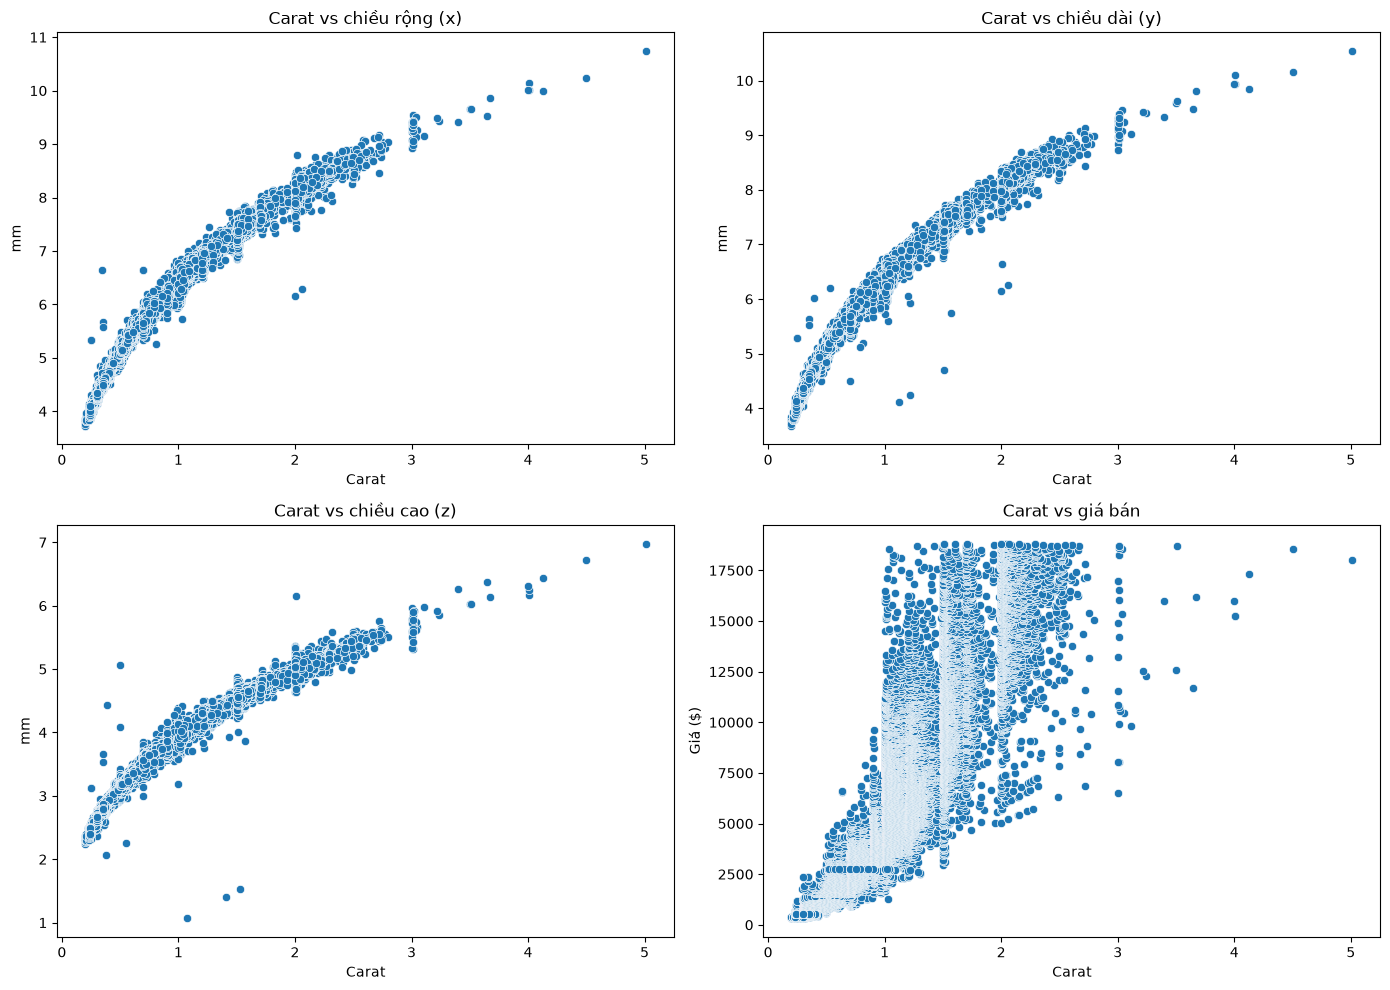

In [10]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# - Dòng 1, Cột 1
sns.scatterplot(data=df, x='carat', y='x', ax=axs[0, 0])
axs[0, 0].set_title('Carat vs chiều rộng (x)')
axs[0, 0].set_xlabel('Carat')
axs[0, 0].set_ylabel('mm')

# - Dòng 1, Cột 2
sns.scatterplot(data=df, x='carat', y='y', ax=axs[0, 1])
axs[0, 1].set_title('Carat vs chiều dài (y)')
axs[0, 1].set_xlabel('Carat')
axs[0, 1].set_ylabel('mm')

# - Dòng 2, Cột 1
sns.scatterplot(data=df, x='carat', y='z', ax=axs[1, 0])
axs[1, 0].set_title('Carat vs chiều cao (z)')
axs[1, 0].set_xlabel('Carat')
axs[1, 0].set_ylabel('mm')

# - Dòng 2, Cột 2
sns.scatterplot(data=df, x='carat', y='price', ax=axs[1, 1])
axs[1, 1].set_title('Carat vs giá bán')
axs[1, 1].set_xlabel('Carat')
axs[1, 1].set_ylabel('Giá ($)')

# 6. Tối ưu khoảng cách giữa các biểu đồ con để tránh đè chữ
plt.tight_layout()

# 7. Hiển thị hình
plt.show()

In [11]:
# Tính toán lại depth từ x, y, z
df['depth_calc'] = (2 * df['z']) / (df['x'] + df['y']) * 100

df['d_depth'] = abs(df['depth'] - df['depth_calc'])

miss_calc = df[df['d_depth'] > 2]

len(miss_calc)

48

In [12]:
df.drop(miss_calc.index, inplace = True)

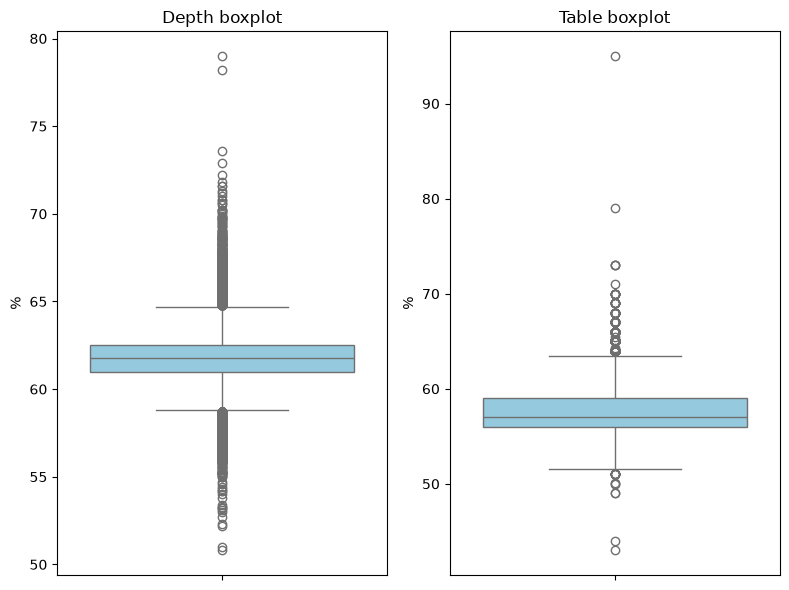

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 6))

sns.boxplot(data=df, y='depth', color='skyblue', ax=axs[0])
axs[0].set_title('Depth boxplot')
axs[0].set_ylabel('%')

# 4. Biểu đồ bên phải: Boxplot của giá/carat theo chất lượng cắt (Cut)
sns.boxplot(data=df, y='table', color='skyblue', ax=axs[1])
axs[1].set_title('Table boxplot')
axs[1].set_ylabel('%')

# 5. Tinh chỉnh khoảng cách và hiển thị
plt.tight_layout()
plt.show()

In [14]:
df = df[(df['depth'] < 75) & (df['table']<90)]

## 4. Phân tích sự ảnh hưởng của các biến đến giá bán của kim cương

**Nhận xét:** Từ biểu đồ scatter giữa giá bán và carat ở trên cho thấy mức giá bán ra luôn nhỏ hơn một ngưỡng (khoảng 19000$). Có thể là do dữ liệu đã bị lọc hoặc những viên kim cương có giá trị lớn khá khan hiếm. Không có dấu hiệu giá bị chặn trần cứng.

In [15]:
print("Giá cao nhất  :", df['price'].max())
print("Số viên >18000$:", (df['price'] > 18000).sum())
print("\n10 mức giá xuất hiện nhiều nhất:")
print(df['price'].value_counts().head(10))

Giá cao nhất  : 18823
Số viên >18000$: 306

10 mức giá xuất hiện nhiều nhất:
price
605    132
625    125
802    125
776    124
828    124
698    121
789    120
544    120
552    113
666    112
Name: count, dtype: int64


### 4.1 Tạo biến mới

- Giá trên mỗi carat (price/carat): đây là một biến quan trọng dùng để giảm bớt nhiễu của trọng lượng ảnh hưởng đến giá bán, thông thường kim cương có trọng lượng càng cao giá trị càng lớn.


In [16]:
# 1) copy sau khi đã lọc xong -> tránh SettingWithCopyWarning
df = df.copy()
# 2) bỏ cột phụ kiểm tra chất lượng (không cần cho phân tích)
df.drop(columns=['depth_calc', 'd_depth'], errors='ignore', inplace=True)
# 3) giá trên mỗi carat
df['price_per_carat'] = df['price'] / df['carat']

# 4) Chia nhóm carat theo qcut
df['carat_bin'] = pd.qcut(df['carat'], 5, duplicates='drop')
print("carat_bin:"); print(df['carat_bin'].value_counts().sort_index())

print("Giá/carat trung bình theo 5 nhóm carat (thấp -> cao):")
print(df.groupby(pd.qcut(df['carat'], 5, duplicates='drop'), observed=True)['price_per_carat'].mean().round(0))

carat_bin:
carat_bin
(0.199, 0.35]    11009
(0.35, 0.53]     10488
(0.53, 0.9]      11992
(0.9, 1.13]       9612
(1.13, 5.01]     10620
Name: count, dtype: int64
Giá/carat trung bình theo 5 nhóm carat (thấp -> cao):
carat
(0.199, 0.35]    2248.0
(0.35, 0.53]     2641.0
(0.53, 0.9]      3655.0
(0.9, 1.13]      5282.0
(1.13, 5.01]     6431.0
Name: price_per_carat, dtype: float64


**Nhận xét:** Giá trên mỗi carat vẫn tăng theo từng nhóm carat, do đó biến giá/carat vẫn chưa khử hết nhiễu trọng lượng.

### 4.2 Phân tích các biến số

In [17]:
df.describe()

,carat,depth,table,price,x,y,z,price_per_carat
count,53721.000000,53721.000000,53721.000000,53721.000000,53721.000000,53721.000000,53721.000000,53721.000000
mean,0.797303,61.748594,57.455479,3929.902347,5.731027,5.733235,3.539142,4008.707930
std,0.473090,1.417245,2.224277,3985.312505,1.118637,1.110624,0.690734,2013.219650
min,0.200000,50.800000,43.000000,326.000000,3.730000,3.680000,2.240000,1051.162791
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000,2478.000000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,3494.623656
75%,1.040000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.030000,4949.586777
max,5.010000,73.600000,79.000000,18823.000000,10.740000,10.540000,6.980000,17828.846154


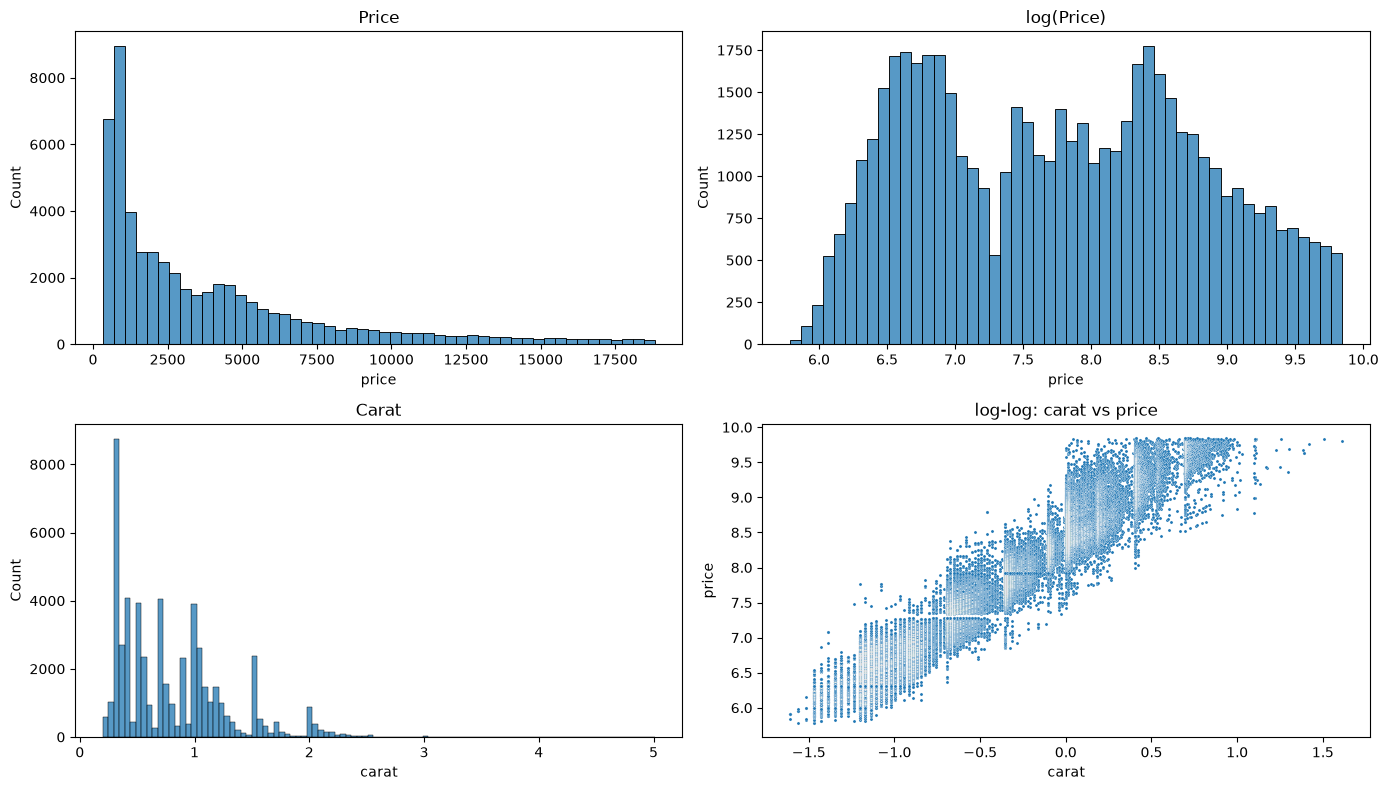

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
sns.histplot(df['price'], bins=50, ax=axs[0,0]); axs[0,0].set_title('Price')
sns.histplot(np.log(df['price']), bins=50, ax=axs[0,1]); axs[0,1].set_title('log(Price)')
sns.histplot(df['carat'], bins=100, ax=axs[1,0]); axs[1,0].set_title('Carat')
sns.scatterplot(x=np.log(df['carat']), y=np.log(df['price']), s=5, ax=axs[1,1])
axs[1,1].set_title('log-log: carat vs price')
plt.tight_layout(); plt.show()

price    1.000000
carat    0.921545
y        0.888971
x        0.887312
z        0.882676
table    0.126256
depth   -0.011128
Name: price, dtype: float64


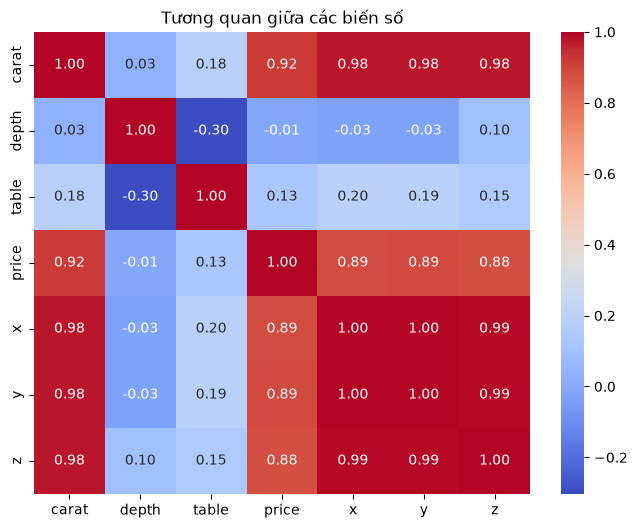

In [19]:
num_cols = ['carat','depth','table','price','x','y','z']
print(df[num_cols].corr()['price'].sort_values(ascending=False))
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Tương quan giữa các biến số'); plt.show()

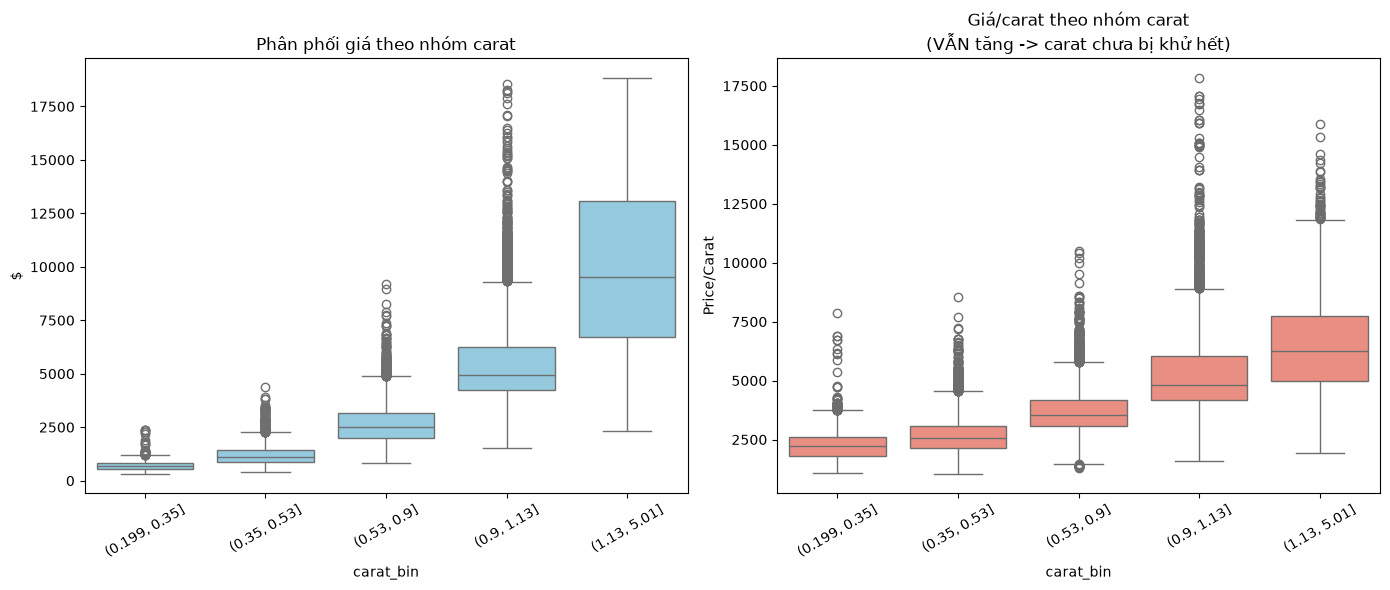

In [20]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
sns.boxplot(data=df, x='carat_bin', y='price', ax=axs[0], color='skyblue')
axs[0].set_title('Phân phối giá theo nhóm carat'); axs[0].set_ylabel('$')
axs[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='carat_bin', y='price_per_carat', ax=axs[1], color='salmon')
axs[1].set_title('Giá/carat theo nhóm carat\n(VẪN tăng -> carat chưa bị khử hết)')
axs[1].set_ylabel('Price/Carat'); axs[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

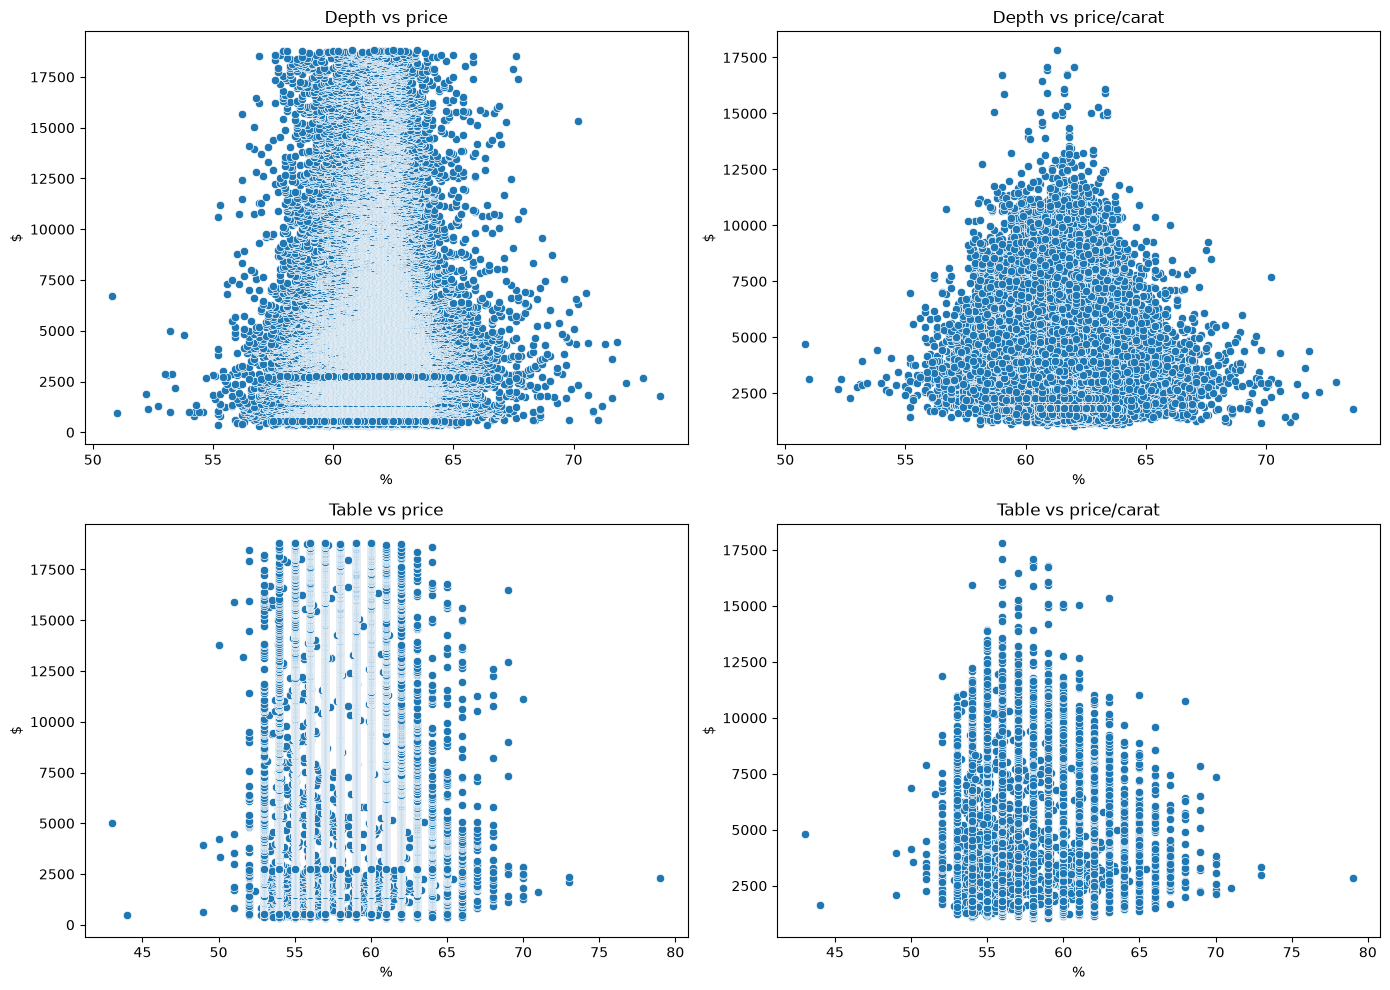

In [21]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# - Dòng 1, Cột 1
sns.scatterplot(data=df, x='depth', y='price', ax=axs[0, 0])
axs[0, 0].set_title('Depth vs price')
axs[0, 0].set_xlabel('%')
axs[0, 0].set_ylabel('$')

# - Dòng 1, Cột 2
sns.scatterplot(data=df, x='depth', y='price_per_carat', ax=axs[0, 1])
axs[0, 1].set_title('Depth vs price/carat')
axs[0, 1].set_xlabel('%')
axs[0, 1].set_ylabel('$')

# - Dòng 2, Cột 1
sns.scatterplot(data=df, x='table', y='price', ax=axs[1, 0])
axs[1, 0].set_title('Table vs price')
axs[1, 0].set_xlabel('%')
axs[1, 0].set_ylabel('$')

# - Dòng 2, Cột 2
sns.scatterplot(data=df, x='table', y='price_per_carat', ax=axs[1, 1])
axs[1, 1].set_title('Table vs price/carat')
axs[1, 1].set_xlabel('%')
axs[1, 1].set_ylabel('$')

# 6. Tối ưu khoảng cách giữa các biểu đồ con để tránh đè chữ
plt.tight_layout()

# 7. Hiển thị hình
plt.show()

**Nhận xét:**

- Biểu đồ Histogram của giá bán lệch trái mạnh, biểu đồ log(price) phân phối đều hơn.
- Số lượng kim cương dồn cục tại các vị trí 0.3/0.5/1.0/1.5 carat.
- Mức độ tương quan tuyến tính giữa các biến x, y, z và carat cao. Price cũng có mức tương quan tuyến tính cao với carat.
- Biểu đồ scatter của log(price)-log(carat) thể hiện mối quan hệ gần tuyến tính, nhưng price vẫn bị chặn trên bởi giá trần.
- Giá/carat vẫn tăng theo từng nhóm carat thể hiện biến 'Giá/carat' vẫn bị ảnh hưởng bởi trọng lượng (carat).
- Hai biến depth và table không ảnh hưởng quá nhiều đến giá bán của kim cương, đa phần các viên kim cương có giá bán tốt có depth và table đều nằm trong khoảng 55-70%.

### 4.3 Phân tích các biến phân loại

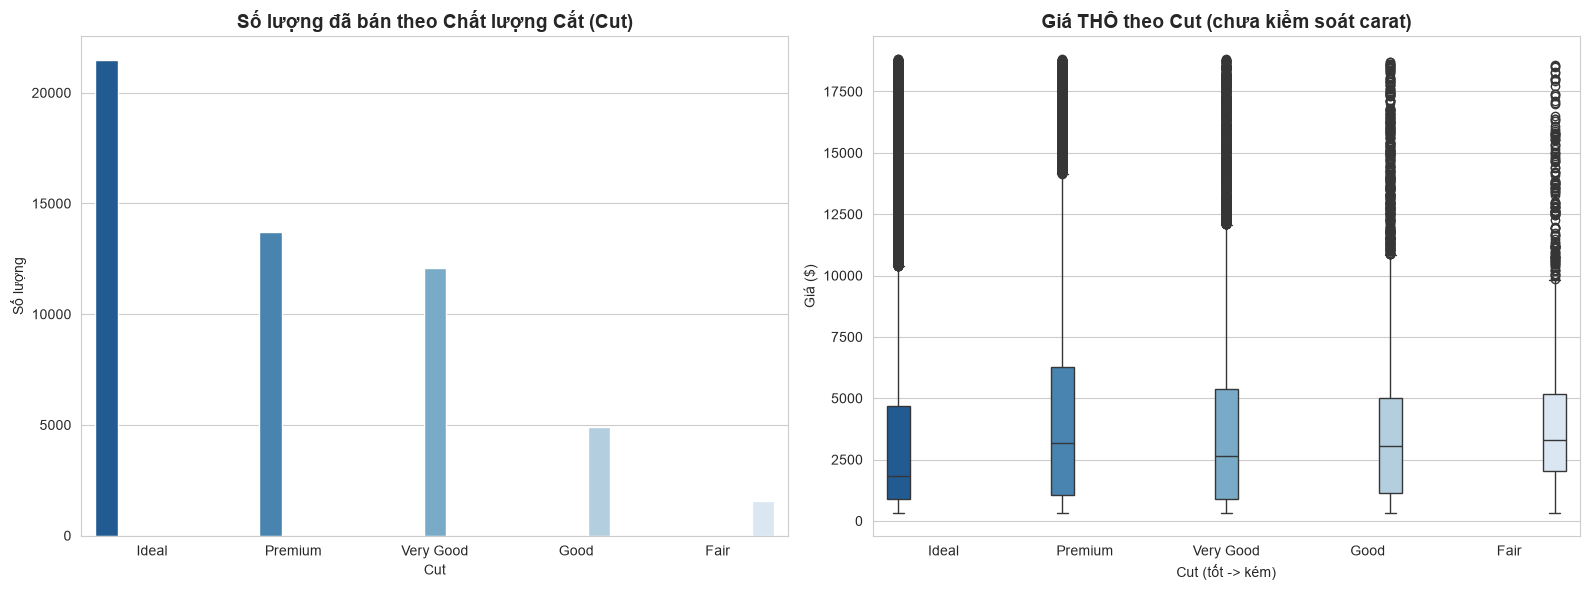

In [22]:
sns.set_style("whitegrid")
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
order_cut = ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
sns.countplot(data=df, x='cut', order=order_cut, hue='cut', palette='Blues_r', legend=False, ax=axs[0])
axs[0].set_title('Số lượng đã bán theo Chất lượng Cắt (Cut)', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Cut'); axs[0].set_ylabel('Số lượng')
sns.boxplot(data=df, x='cut', y='price', order=order_cut, hue='cut', palette='Blues_r', legend=False, ax=axs[1])
axs[1].set_title('Giá THÔ theo Cut (chưa kiểm soát carat)', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Cut (tốt -> kém)'); axs[1].set_ylabel('Giá ($)')
plt.tight_layout(); plt.show()

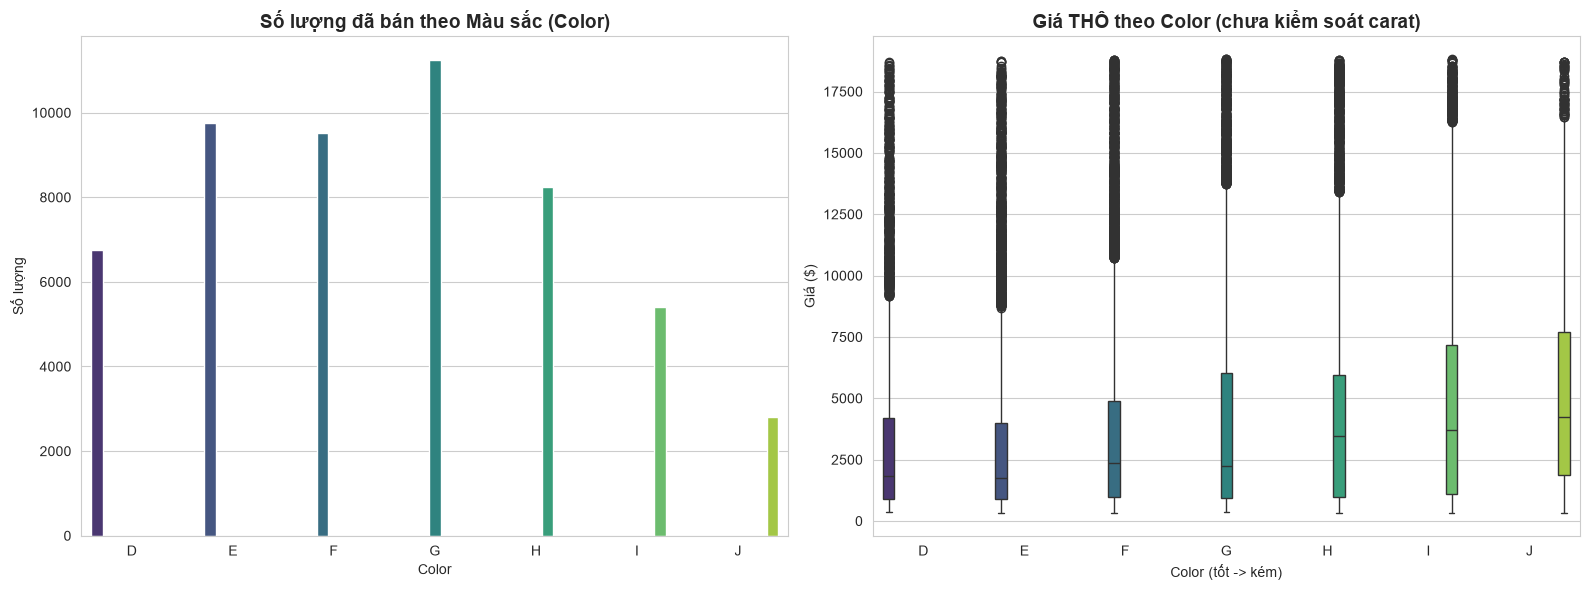

In [23]:
sns.set_style("whitegrid")
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
order_color = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
sns.countplot(data=df, x='color', order=order_color, hue='color', palette='viridis', legend=False, ax=axs[0])
axs[0].set_title('Số lượng đã bán theo Màu sắc (Color)', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Color'); axs[0].set_ylabel('Số lượng')
sns.boxplot(data=df, x='color', y='price', order=order_color, hue='color', palette='viridis', legend=False, ax=axs[1])
axs[1].set_title('Giá THÔ theo Color (chưa kiểm soát carat)', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Color (tốt -> kém)'); axs[1].set_ylabel('Giá ($)')
plt.tight_layout(); plt.show()

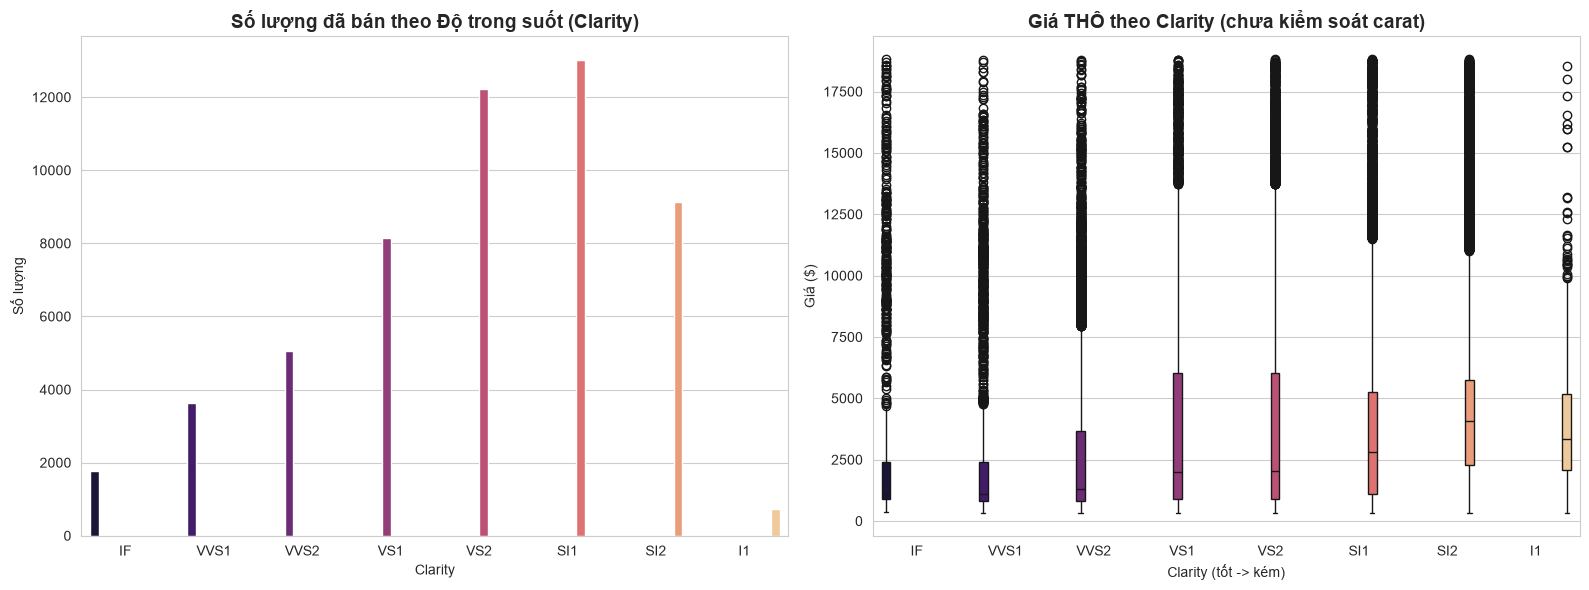

In [24]:
sns.set_style("whitegrid")
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
order_clarity = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']
sns.countplot(data=df, x='clarity', order=order_clarity, hue='clarity', palette='magma', legend=False, ax=axs[0])
axs[0].set_title('Số lượng đã bán theo Độ trong suốt (Clarity)', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Clarity'); axs[0].set_ylabel('Số lượng')
sns.boxplot(data=df, x='clarity', y='price', order=order_clarity, hue='clarity', palette='magma', legend=False, ax=axs[1])
axs[1].set_title('Giá THÔ theo Clarity (chưa kiểm soát carat)', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Clarity (tốt -> kém)'); axs[1].set_ylabel('Giá ($)')
plt.tight_layout(); plt.show()

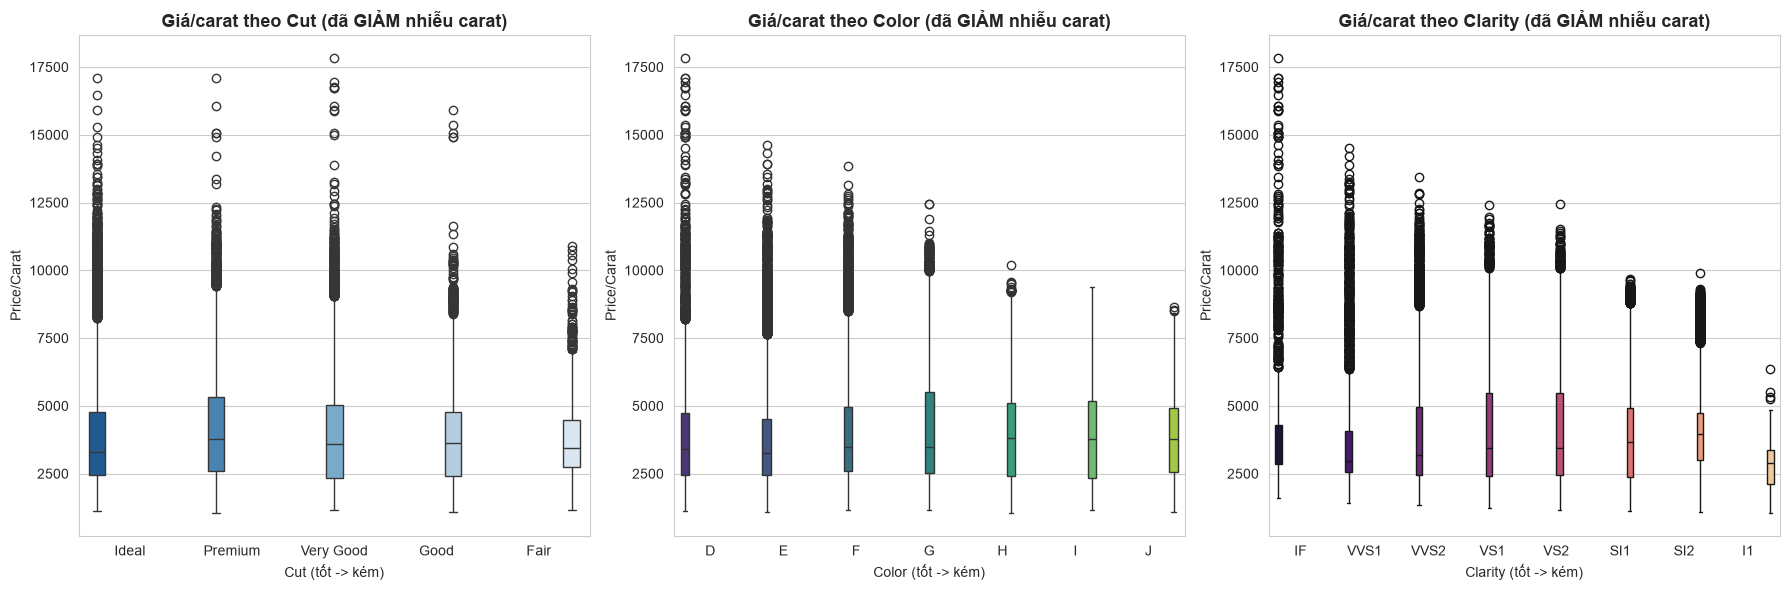

In [25]:
sns.set_style("whitegrid")
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
sns.boxplot(data=df, x='cut', y='price_per_carat', order=['Ideal','Premium','Very Good','Good','Fair'],
            hue='cut', palette='Blues_r', legend=False, ax=axs[0])
axs[0].set_title('Giá/carat theo Cut (đã GIẢM nhiễu carat)', fontsize=13, fontweight='bold')
axs[0].set_ylabel('Price/Carat'); axs[0].set_xlabel('Cut (tốt -> kém)')
sns.boxplot(data=df, x='color', y='price_per_carat', order=['D','E','F','G','H','I','J'],
            hue='color', palette='viridis', legend=False, ax=axs[1])
axs[1].set_title('Giá/carat theo Color (đã GIẢM nhiễu carat)', fontsize=13, fontweight='bold')
axs[1].set_ylabel('Price/Carat'); axs[1].set_xlabel('Color (tốt -> kém)')
sns.boxplot(data=df, x='clarity', y='price_per_carat', order=['IF','VVS1','VVS2','VS1','VS2','SI1','SI2','I1'],
            hue='clarity', palette='magma', legend=False, ax=axs[2])
axs[2].set_title('Giá/carat theo Clarity (đã GIẢM nhiễu carat)', fontsize=13, fontweight='bold')
axs[2].set_ylabel('Price/Carat'); axs[2].set_xlabel('Clarity (tốt -> kém)')
plt.tight_layout(); plt.show()

**So sánh 4C KHI ĐÃ KIỂM SOÁT CARAT**


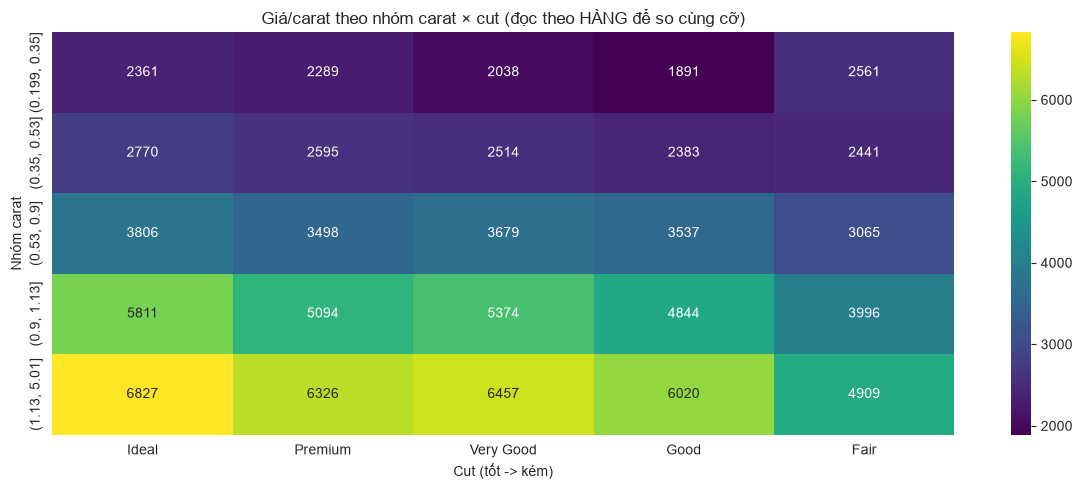

In [26]:
piv = (df.groupby(['carat_bin', 'cut'], observed=True)['price_per_carat']
         .mean().unstack())
piv = piv[['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']]
plt.figure(figsize=(12, 5))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='viridis')
plt.title('Giá/carat theo nhóm carat × cut (đọc theo HÀNG để so cùng cỡ)')
plt.ylabel('Nhóm carat'); plt.xlabel('Cut (tốt -> kém)')
plt.tight_layout(); plt.show()

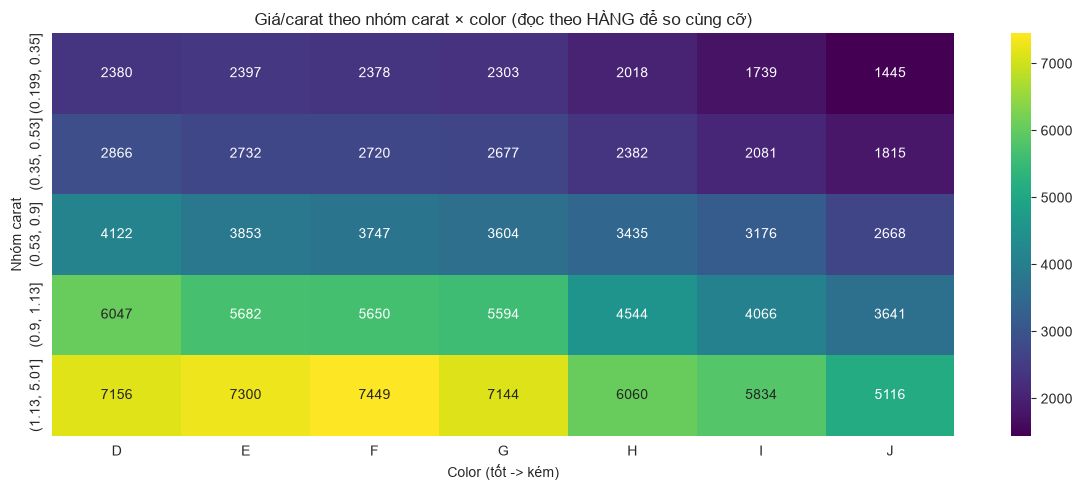

In [27]:
piv = (df.groupby(['carat_bin', 'color'], observed=True)['price_per_carat']
         .mean().unstack())
piv = piv[['D', 'E', 'F', 'G', 'H', 'I', 'J']]
plt.figure(figsize=(12, 5))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='viridis')
plt.title('Giá/carat theo nhóm carat × color (đọc theo HÀNG để so cùng cỡ)')
plt.ylabel('Nhóm carat'); plt.xlabel('Color (tốt -> kém)')
plt.tight_layout(); plt.show()

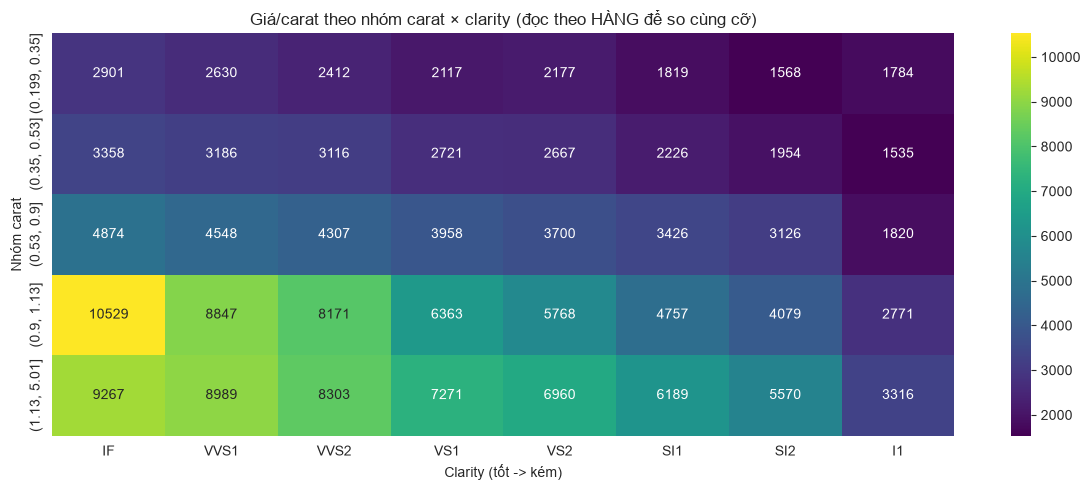

In [28]:
piv = (df.groupby(['carat_bin', 'clarity'], observed=True)['price_per_carat']
         .mean().unstack())
piv = piv[['IF','VVS1','VVS2','VS1','VS2','SI1','SI2','I1']]
plt.figure(figsize=(12, 5))
sns.heatmap(piv, annot=True, fmt='.0f', cmap='viridis')
plt.title('Giá/carat theo nhóm carat × clarity (đọc theo HÀNG để so cùng cỡ)')
plt.ylabel('Nhóm carat'); plt.xlabel('Clarity (tốt -> kém)')
plt.tight_layout(); plt.show()

In [29]:
mask = df['carat'].between(0.9, 1.1)
print(f"Số viên trong dải 0.9-1.1 carat: {mask.sum()}\n")
for col in ['cut', 'color', 'clarity']:
    g = df[mask].groupby(col, observed=True)['price'].mean()
    print(f"{col:8s}: chênh lệch giá TB (max - min) = {g.max()-g.min():,.0f}$")
print("\n=> Biến tạo chênh lệch lớn nhất khi cùng cỡ carat = biến ảnh hưởng mạnh nhất.")

Số viên trong dải 0.9-1.1 carat: 10293

cut     : chênh lệch giá TB (max - min) = 1,958$
color   : chênh lệch giá TB (max - min) = 2,205$
clarity : chênh lệch giá TB (max - min) = 7,916$

=> Biến tạo chênh lệch lớn nhất khi cùng cỡ carat = biến ảnh hưởng mạnh nhất.


**Nhận xét:** Trong 3 biến phân loại thì Độ trong suốt (Clarity) có mức ảnh hưởng lớn nhất. Trong cùng nhóm theo carat, giá/carat trung bình tăng đều khi chất lượng clarity tăng. Mức độ chênh lệch về giá của biến clarity trong dải 0.9-1.1 carat cũng là cao nhất, cao hơn 2 biến cut và color khoảng 4 lần.

## 5. Tổng hợp và kết luận

Trả lời câu hỏi ban đầu:
- Yếu tố ảnh hưởng đến giá nhiều nhất là trọng lượng (carat): tương quan với giá xấp xỉ 0.92, áp đảo mọi yếu tố khác. Nói cách khác: kích thước quyết định phần lớn giá tiền.
- Trong '4C', khi so cùng kích cỡ, độ trong suốt (clarity) là yếu tố tạo chênh lệch giá lớn nhất, chênh giá do clarity cao gấp ~4 lần so với cut hay color. Trực giác dân trong ngành '4C đều quan trọng' đúng một phần: clarity ảnh hưởng mạnh, nhưng cut lại ảnh hưởng ít bất ngờ khi đã cùng cỡ.
- Depth và table gần như không ảnh hưởng tới giá (tương quan ~0), chúng chỉ nên dùng để lọc hàng lỗi, không phải để định giá.

*Điểm cần lưu ý:* đã làm sạch 146 dòng trùng, 19 dòng kích thước = 0, và ~50 dòng vi phạm công thức hình học của kim cương. Dữ liệu gần như chỉ gồm viên dưới ~19.000 USD (do lọc hoặc do viên đắt hiếm), không có dấu hiệu giá bị chặn trần cứng.

*Hạn chế:* việc so 4C dựa trên chia nhóm carat; ở nhóm viên lớn, các viên trong cùng nhóm vẫn chênh cỡ khá nhiều nên kết luận ở phân khúc cao cấp cần thận trọng.

**Bước tiếp theo:** xây mô hình dự đoán giá để định lượng chính xác đóng góp của từng yếu tố (kiểm soát carat liên tục thay vì chia nhóm), phục vụ định giá tự động.